<a href="https://colab.research.google.com/github/shadinyri/bank_account_fraud_detection/blob/main/%20%20%20%20baf_predictive_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q pandas pyarrow lightgbm scikit-learn

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Data Loading & Dictionary Construction
Loading all BAF dataset variants from the directory into a dictionary of Pandas DataFrames.

In [ ]:
import glob
import pandas as pd

data_paths = glob.glob("/content/drive/MyDrive/BAF_Project/archive/*.csv")

def read_dataset(path):
    return pd.read_csv(path)

def get_variant(path):
    return path.split("/")[-1].split(".")[0]

dataframes = {
    get_variant(path): read_dataset(path) for path in data_paths
}

print(dataframes.keys())

dict_keys(['Base', 'Variant I', 'Variant II', 'Variant III', 'Variant IV', 'Variant V'])


## Data Preprocessing & Temporal Train/Test Split
Filtering the Base variant, defining sensitive attributes for fairness evaluation, encoding categorical features, and splitting data based on the 6-month/2-month temporal rule.

In [ ]:
df = dataframes['Base'].copy()
# Extract sensitive attributes for governance BEFORE dropping them
sensitive_features = pd.DataFrame({
    'is_older': (df['customer_age'] >= 50).astype(int),
    # Align with BAF paper's exact definitions instead of quantiles
    'is_low_income': (df['income'] < 0.5).astype(int),
    # Map string categories mathematically equivalent to paper's '>= 3' rule
    'is_unemployed': df['employment_status'].isin(['CD', 'CE', 'CF', 'CG']).astype(int)
})
# Extract sensitive attributes for governance BEFORE dropping theme

X = df.drop(columns=['fraud_bool', 'customer_age'])
y = df['fraud_bool']

# Use native pandas 'category' dtype
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
    X[col] = X[col].astype('category')

# Temporal split (6 months train, 2 months test)
train_mask = X['month'] <= 5
test_mask = X['month'] > 5

X_train, y_train = X[train_mask].drop(columns=['month']), y[train_mask]
X_test, y_test = X[test_mask].drop(columns=['month']), y[test_mask]

# Save test-set sensitive attributes for later fairness evaluation
sensitive_test = sensitive_features[test_mask]

print(f"training_data: {X_train.shape}")
print(f"test_data: {X_test.shape}")

training_data: (794989, 29)
test_data: (205011, 29)


## Exploratory Data Analysis: Feature Correlation
Visualizing feature correlations to detect multicollinearity and redundant variables before modeling.

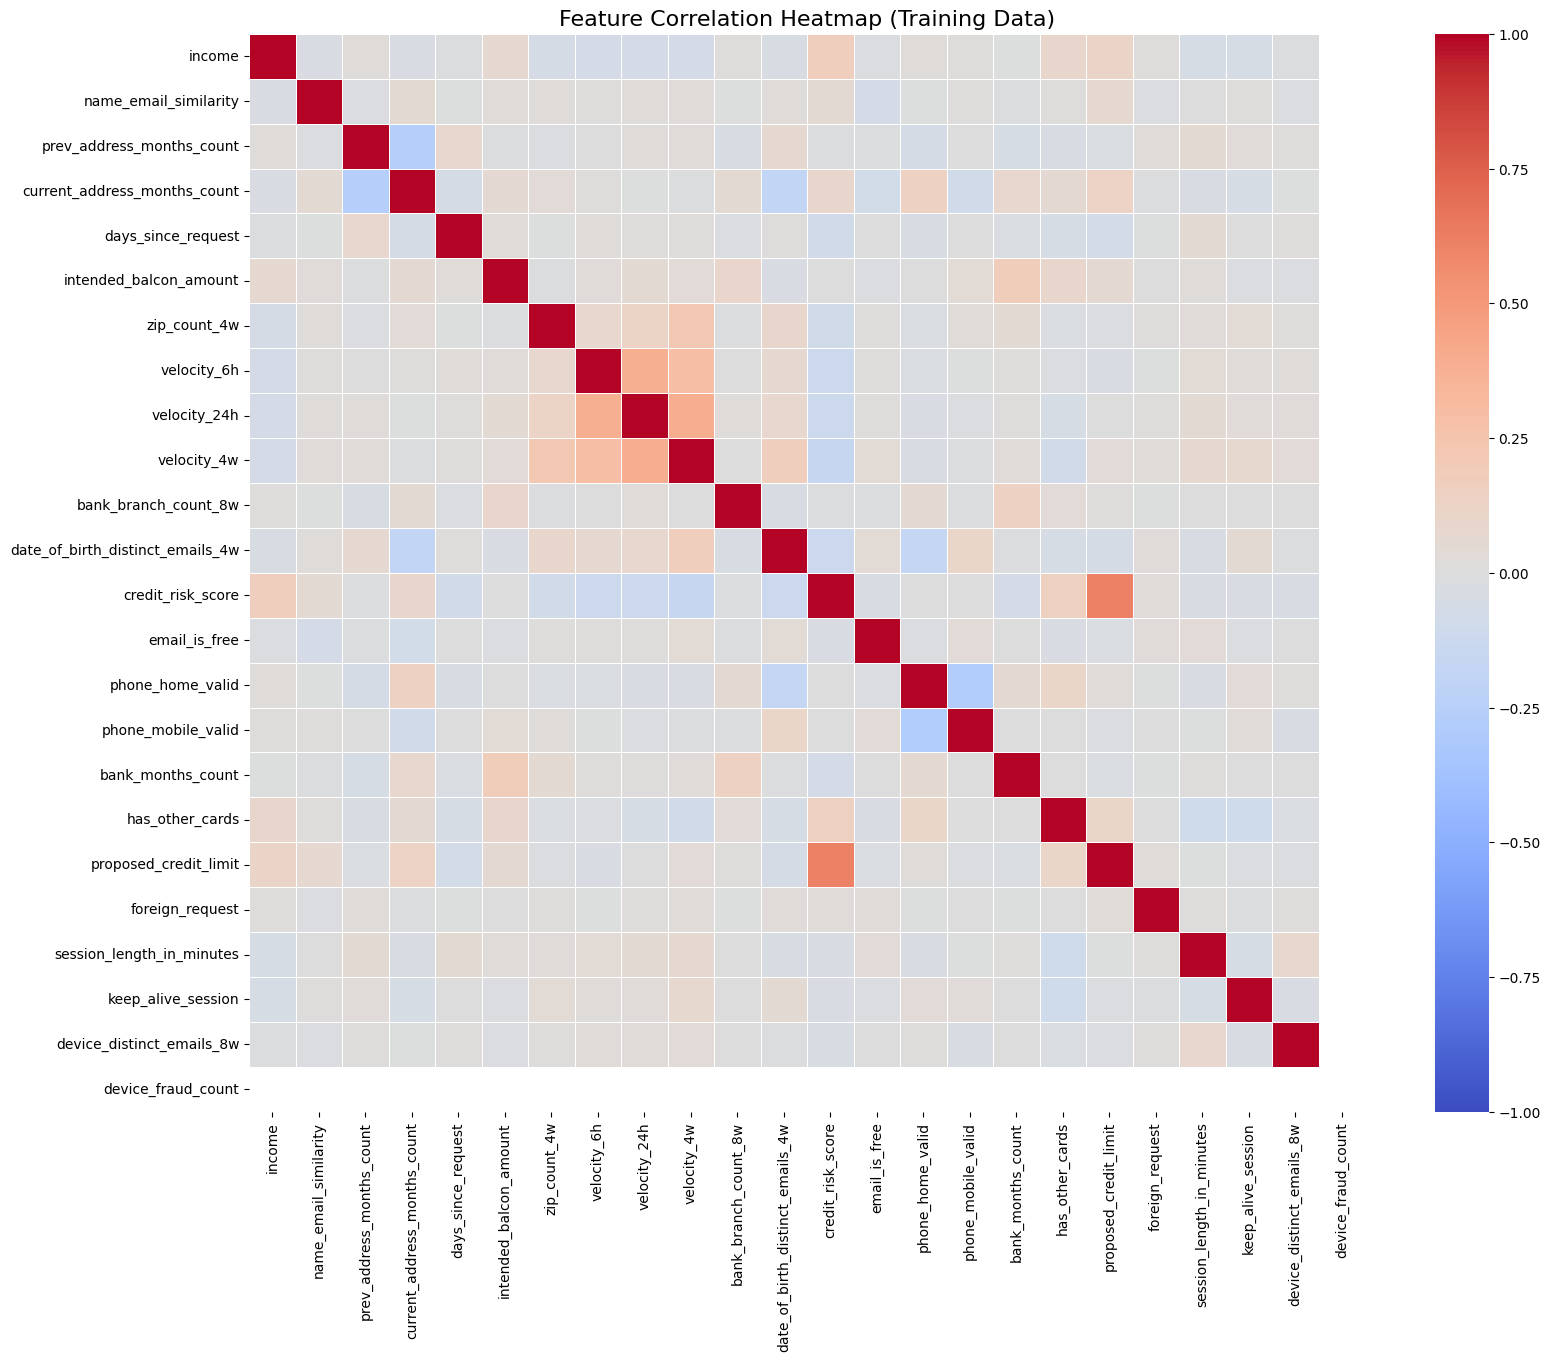

Highly correlated feature pairs (> 0.8):
No pair feature found with correlation magnitude higher than 0.8.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# FIX: Add numeric_only=True to ignore categorical string columns
corr_matrix = X_train.corr(numeric_only=True)

plt.figure(figsize=(18, 14))

sns.heatmap(
    corr_matrix,
    annot=False,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    vmin=-1,
    vmax=1
)

plt.title('Feature Correlation Heatmap (Training Data)', fontsize=16)
plt.show()

# Identify highly correlated feature pairs (threshold > 0.8)
print("Highly correlated feature pairs (> 0.8):")
found_high_corr = False
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            feature_1 = corr_matrix.columns[i]
            feature_2 = corr_matrix.columns[j]
            corr_value = corr_matrix.iloc[i, j]
            print(f"- {feature_1} and {feature_2}: {corr_value:.4f}")
            found_high_corr = True

if not found_high_corr:
    print("No pair feature found with correlation magnitude higher than 0.8.")

## Identifying Moderate-to-Strong Feature Correlations
Extracting and ranking feature pairs with an absolute correlation magnitude greater than 0.5.

In [ ]:
# 1. Calculate the standard correlation matrix (without absolute yet)
# Add numeric_only=True to ignore categorical string columns
corr_matrix = X_train.corr(numeric_only=True)

# 2. Unstack and remove self-correlations (1.0) and duplicates
unstacked_corr = corr_matrix.unstack()
pairs = unstacked_corr[unstacked_corr < 1.0].drop_duplicates()

# 3. Define the threshold for strong correlation
threshold = 0.5

# 4. Filter pairs where the ABSOLUTE correlation is greater than the threshold
# This captures both > 0.5 and < -0.5
strong_pairs = pairs[pairs.abs() > threshold]

# 5. Conditional output (if/else)
if strong_pairs.empty:
    print(f"No pair feature found with correlation magnitude higher than {threshold}.")
else:
    print(f"Highly correlated feature pairs (magnitude > {threshold}):")
    # Sort by absolute value to show the strongest relationships first
    print(strong_pairs.reindex(strong_pairs.abs().sort_values(ascending=False).index))

Highly correlated feature pairs (magnitude > 0.5):
credit_risk_score  proposed_credit_limit    0.612478
dtype: float64


## Baseline Model Training (Pre-Optimization)
Training an initial LightGBM classifier using built-in class weight balancing to establish a baseline performance metric.

In [ ]:
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, roc_curve

lgb_model_balanced = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    is_unbalance=True,
    random_state=42,
    n_jobs=-1
)

print("Training LightGBM model... This may take a few seconds.")
lgb_model_balanced.fit(X_train, y_train)

print("Evaluating the model on test data...")
y_pred = lgb_model_balanced.predict(X_test)
y_proba = lgb_model_balanced.predict_proba(X_test)[:, 1]

auc_score = roc_auc_score(y_test, y_proba)
print(f"\nROC-AUC Score: {auc_score:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Training LightGBM model... This may take a few seconds.
[LightGBM] [Info] Number of positive: 8151, number of negative: 786838
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.156441 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3195
[LightGBM] [Info] Number of data points in the train set: 794989, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.010253 -> initscore=-4.569882
[LightGBM] [Info] Start training from score -4.569882
Evaluating the model on test data...

ROC-AUC Score: 0.8863

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.81      0.89    202133
           1       0.06      0.80      0.11      2878

    accuracy                           0.81    205011
   macro avg       0.53      0.81      0.50    205011
weighted avg       0.98     

## Threshold Moving: Manual Adjustment
Demonstrating the impact of manually shifting the decision threshold on the trade-off between Recall and False Positive Rate.

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# 1. Get the probabilities for the positive class (Fraud) from the balanced model
probabilities = lgb_model_balanced.predict_proba(X_test)[:, 1]

# 2. Set custom threshold
custom_threshold = best_threshold

# 3. Apply the rule: if probability >= threshold, label as 1 (Fraud), else 0 (Normal)
y_pred_custom = (probabilities >= custom_threshold).astype(int)

# 4. Print the new evaluation metrics
print(f"--- Results for Custom Threshold: {custom_threshold} ---")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_custom))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_custom))

--- Results for Custom Threshold: 0.1 ---

Confusion Matrix:
[[ 92067 110066]
 [   110   2768]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.46      0.63    202133
           1       0.02      0.96      0.05      2878

    accuracy                           0.46    205011
   macro avg       0.51      0.71      0.34    205011
weighted avg       0.99      0.46      0.62    205011



## Hyperparameter Tuning with Optuna & Cross-Validation
Optimizing LightGBM hyperparameters using Bayesian optimization and Stratified K-Fold cross-validation to maximize ROC-AUC.

In [ ]:
#!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 21.2 MB/s eta 0:00:00


In [ ]:
import optuna
from sklearn.model_selection import StratifiedKFold
import lightgbm as lgb
from sklearn.metrics import roc_auc_score
import numpy as np

# 1. Define the objective function for Optuna
def objective(trial):
    # Define the hyperparameter search space
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'is_unbalance': False,#Set False to output raw, unweighted probabilities for manual Threshold Moving
        'random_state': 42,
        'n_jobs': -1
    }

    # 2. Setup Stratified K-Fold cross-validation
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    cv_scores = []

    # 3. Train and evaluate the model on each fold
    for train_idx, val_idx in cv.split(X_train, y_train):
        X_fold_train = X_train.iloc[train_idx]
        X_fold_val = X_train.iloc[val_idx]
        y_fold_train = y_train.iloc[train_idx]
        y_fold_val = y_train.iloc[val_idx]

        # Initialize and train the LightGBM model
        model = lgb.LGBMClassifier(**params)
        model.fit(X_fold_train, y_fold_train)

        # Predict probabilities and calculate ROC-AUC score
        preds = model.predict_proba(X_fold_val)[:, 1]
        score = roc_auc_score(y_fold_val, preds)
        cv_scores.append(score)

    # 4. Return the average score across all folds
    return np.mean(cv_scores)

# 5. Create a study object and optimize the objective function
print("Starting Optuna search... Please wait.")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

# 6. Print the best hyperparameters found
print("\n--- Best Parameters Found ---")
print(study.best_params)
print(f"Best ROC-AUC Score: {study.best_value:.4f}")

[I 2026-10-01 19:07:13,448] A new study created in memory with name: no-name-4c5c5a53-0fda-41ac-9587-64f188fb19cb


Starting Optuna search... Please wait.
[LightGBM] [Info] Number of positive: 5434, number of negative: 524558
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.086156 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3195
[LightGBM] [Info] Number of data points in the train set: 529992, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.010253 -> initscore=-4.569880
[LightGBM] [Info] Start training from score -4.569880
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No fur

[I 2026-10-01 19:07:44,102] Trial 0 finished with value: 0.8933392661555656 and parameters: {'n_estimators': 167, 'learning_rate': 0.07338146607386734, 'num_leaves': 82, 'max_depth': 3}. Best is trial 0 with value: 0.8933392661555656.


[LightGBM] [Info] Number of positive: 5434, number of negative: 524558
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.045536 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3195
[LightGBM] [Info] Number of data points in the train set: 529992, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.010253 -> initscore=-4.569880
[LightGBM] [Info] Start training from score -4.569880
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

[I 2026-10-01 19:08:19,455] Trial 1 finished with value: 0.8716926885891145 and parameters: {'n_estimators': 250, 'learning_rate': 0.010395811983542847, 'num_leaves': 89, 'max_depth': 3}. Best is trial 0 with value: 0.8933392661555656.


...

[LightGBM] [Info] Number of positive: 5434, number of negative: 524558
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.061550 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3195
[LightGBM] [Info] Number of data points in the train set: 529992, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.010253 -> initscore=-4.569880
[LightGBM] [Info] Start training from score -4.569880
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

[I 2026-10-01 19:20:04,917] Trial 18 finished with value: 0.8945412664083375 and parameters: {'n_estimators': 210, 'learning_rate': 0.059405625771599004, 'num_leaves': 36, 'max_depth': 4}. Best is trial 16 with value: 0.8962229439465244.


[LightGBM] [Info] Number of positive: 5434, number of negative: 524558
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.054222 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3195
[LightGBM] [Info] Number of data points in the train set: 529992, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.010253 -> initscore=-4.569880
[LightGBM] [Info] Start training from score -4.569880
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

[I 2026-10-01 19:20:56,828] Trial 19 finished with value: 0.8940496429494083 and parameters: {'n_estimators': 263, 'learning_rate': 0.0420230554108372, 'num_leaves': 68, 'max_depth': 4}. Best is trial 16 with value: 0.8962229439465244.



--- Best Parameters Found ---
{'n_estimators': 246, 'learning_rate': 0.09509063929243783, 'num_leaves': 86, 'max_depth': 3}
Best ROC-AUC Score: 0.8962


## Final Model Training with Optimized Hyperparameters
Training the final LightGBM model dynamically using the best hyperparameters discovered by Optuna, and updating the project checkpoint.

In [ ]:
import lightgbm as lgb
import joblib

lgb_model_optuna = lgb.LGBMClassifier(
    n_estimators=246,
    learning_rate=0.09509063929243783,
    num_leaves=86,
    max_depth=3,
    is_unbalance=False,
    random_state=42,
    n_jobs=-1
)

print("Training the final model...")
lgb_model_optuna.fit(X_train, y_train)
print("Training complete!")

save_path = '/content/drive/MyDrive/fraud_project_checkpoint.pkl'
project_state = {
    'X_train': X_train,
    'X_test': X_test,
    'y_train': y_train,
    'y_test': y_test,
    'model': lgb_model_balanced,
    'optuna_model': lgb_model_optuna
}
joblib.dump(project_state, save_path)
print("Saved successfully.")

Training the final model...
[LightGBM] [Info] Number of positive: 8151, number of negative: 786838
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.071177 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3195
[LightGBM] [Info] Number of data points in the train set: 794989, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.010253 -> initscore=-4.569882
[LightGBM] [Info] Start training from score -4.569882
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits

## Threshold Optimization: Precision-Recall Curve & F1-Score Maximization
Visualizing the Precision-Recall trade-off and mathematically determining the threshold that maximizes the F1-Score for imbalanced classification.

--- Optimal Threshold Found: 0.1226 ---
Expected Precision: 0.2543
Expected Recall: 0.3002
Expected F1-Score: 0.2754


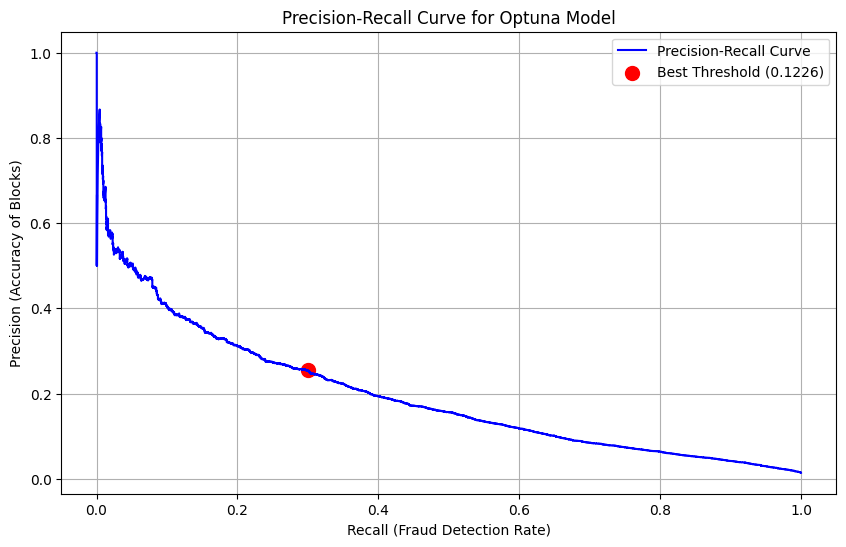

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve
import numpy as np

y_probs = lgb_model_optuna.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)

f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)

best_index = np.argmax(f1_scores)
best_threshold = thresholds[best_index]
best_precision = precisions[best_index]
best_recall = recalls[best_index]
best_f1 = f1_scores[best_index]

print(f"--- Optimal Threshold Found: {best_threshold:.4f} ---")
print(f"Expected Precision: {best_precision:.4f}")
print(f"Expected Recall: {best_recall:.4f}")
print(f"Expected F1-Score: {best_f1:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(recalls, precisions, label='Precision-Recall Curve', color='blue')
plt.scatter([best_recall], [best_precision], color='red', marker='o', s=100,
            label=f'Best Threshold ({best_threshold:.4f})')
plt.xlabel('Recall (Fraud Detection Rate)')
plt.ylabel('Precision (Accuracy of Blocks)')
plt.title('Precision-Recall Curve for Optuna Model')
plt.legend()
plt.grid(True)
plt.show()

## Business Metric Evaluation: The 5% FPR Strategy
Evaluating model performance against the official paper's benchmark, locking the False Positive Rate at exactly 5% to measure business-viable Recall.

In [ ]:
import numpy as np

# Get probability predictions from the optimal model
y_probs = lgb_model_optuna.predict_proba(X_test)[:, 1]

# Calculate ROC curve metrics
# FIX: Removed 'metrics.' prefix
fpr, tpr, thresholds_roc = roc_curve(y_test, y_probs)

# Find the exact point where False Positive Rate (FPR) is 5% or less
idx = np.where(fpr <= 0.05)[0][-1]
paper_threshold = thresholds_roc[idx]
paper_recall = tpr[idx]

# Print the results to compare with the official paper
print("\n--- Paper's Evaluation Rule (FPR = 5%) ---")
print(f"Required Threshold: {paper_threshold:.4f}")
print(f"Our Model's Recall at 5% FPR: {paper_recall:.4f}")


--- Paper's Evaluation Rule (FPR = 5%) ---
Required Threshold: 0.0442
Our Model's Recall at 5% FPR: 0.5479


## Business Metric Evaluation: The Balanced Strategy (Max F1)
Extracting the False Positive Rate and Recall for the F1-optimized threshold to evaluate its viability as a balanced business strategy.

In [ ]:
# Dynamically find the index closest to the F1-optimized threshold
idx_optimal = np.argmin(np.abs(thresholds_roc - 0.1226))

exact_fpr = fpr[idx_optimal]
exact_recall = tpr[idx_optimal]

print(f"--- Metrics for Threshold 12.26% ---")
print(f"False Positive Rate (FPR): {exact_fpr:.4f} (or {exact_fpr * 100:.2f}%)")
print(f"True Positive Rate (Recall): {exact_recall:.4f} (or {exact_recall * 100:.2f}%)")


--- Metrics for Threshold 12.26% ---
False Positive Rate (FPR): 0.0125 (or 1.25%)
True Positive Rate (Recall): 0.3002 (or 30.02%)


##Model Governance: Fairness & Predictive Equality
Evaluating the final business threshold (5% global FPR) for disparate impact across protected groups.


In [ ]:
def calculate_fpr(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fp / (fp + tn)

# Generate binary predictions using the strict 5% FPR threshold calculated earlier
# (Make sure 'paper_threshold' and 'y_probs' exist in memory from your previous cell)
y_pred_business = (y_probs >= paper_threshold).astype(int)

fairness_metrics = []

for attr in sensitive_test.columns:
    # Split test data by sensitive group
    group_1_mask = sensitive_test[attr] == 1
    group_0_mask = sensitive_test[attr] == 0

    fpr_1 = calculate_fpr(y_test[group_1_mask], y_pred_business[group_1_mask])
    fpr_0 = calculate_fpr(y_test[group_0_mask], y_pred_business[group_0_mask])

    # Predictive Equality Ratio (FPR ratio between groups)
    fpr_ratio = fpr_1 / fpr_0 if fpr_0 > 0 else np.nan

    fairness_metrics.append({
        'Protected Attribute': attr,
        'FPR (Group=1)': round(fpr_1, 4),
        'FPR (Group=0)': round(fpr_0, 4),
        'FPR Ratio (Predictive Equality)': round(fpr_ratio, 4)
    })

fairness_df = pd.DataFrame(fairness_metrics)
print("--- Algorithmic Fairness Audit (at 5% Global FPR) ---\n")
print(fairness_df.to_string(index=False))

--- Algorithmic Fairness Audit (at 5% Global FPR) ---

Protected Attribute  FPR (Group=1)  FPR (Group=0)  FPR Ratio (Predictive Equality)
           is_older         0.0978         0.0405                           2.4133
      is_low_income         0.0208         0.0611                           0.3399
      is_unemployed         0.0055         0.0539                           0.1021
